In [1]:
# Fortaleza, 18 de Agosto de 2025
# Autor: Michel Gonzaga dos Santos 
# Código referente à questão 4 do Teste Teórico

## Questão 4 do Teste Teórico

Este notebook tem como objetivo realizar uma **análise crítica** dos dados fornecidos, com a finalidade de responder à **Questão 4 do Teste Teórico**, que é enunciada da seguinte forma:

---
> **Questão 4**  
> Você recebeu um dataset de vendas de um produto financeiro. Com base nos dados fornecidos, identifique os principais ofensores que estão impactando negativamente a conversão.  Em seguida, descreva um plano de ação detalhado para solucionar esses problemas e melhorar a taxa de conversão. Certifique-se de abordar os desafios específicos mencionados nos dados e apresentar estratégias claras para superá-los.
---

Nesse contexto, esse notebook está organizado da seguinte forma:

### Sumário
- [Bibliotecas](#bibliotecas)
- [Leitura dos Dados](#leitura-dos-dados)
- [Análise Exploratória](#analise-exploratoria)






## Bibliotecas
Nesta seção, apresentamos as bibliotecas utilizadas na análise, acompanhadas de suas respectivas versões, de modo a assegurar a reprodutibilidade e a consistência dos resultados.

In [2]:
# Bibliotecas para manipulação dos dados
import numpy as np
import pandas as pd

# Bibliotecas de visualização de dados
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import plotly 

# Biblioteca de monitoramento
import logging
logging.getLogger().setLevel(logging.CRITICAL)

In [3]:
# Packages version
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')
print(f'logging: {logging.__version__}')

pandas: 2.3.1
numpy: 2.2.6
matplotlib: 3.10.3
seaborn: 0.13.2
logging: 0.5.1.2


## Leitura dos Dados

In [3]:
df = pd.read_excel('./Teorico_1 (5).xlsx')
df

,ID Cliente,Data e Hora de Inclusão da Proposta,Última Fase,Status,Data e Hora da Última Fase da Proposta
0,613,2023-01-01 07:18:00,Simulação,Cancelada,2023-01-02 04:53:00
1,287,2023-01-01 07:42:00,Análise política de crédito,Cancelada,2023-01-02 06:18:00
2,937,2023-01-01 09:26:00,Averbação,Integrada,2023-01-01 17:10:00
3,749,2023-01-01 16:18:00,Pagamento,Integrada,2023-01-02 04:19:00
4,56,2023-01-01 16:44:00,Pagamento,Integrada,2023-01-02 00:02:00
...,...,...,...,...,...
1059,674,2023-06-27 09:47:00,Simulação,Andamento,2023-06-27 18:31:00
1060,116,2023-06-27 11:23:00,Averbação,Integrada,2023-06-28 07:46:00
1061,792,2023-06-27 14:50:00,Análise política de crédito,Andamento,2023-06-28 08:18:00
1062,1001,2023-06-27 15:50:00,Análise política de crédito,Andamento,2023-06-28 04:43:00


Os dados apresentam os seguintes formatos:

In [4]:
df.dtypes

ID Cliente                                         int64
Data e Hora de Inclusão da Proposta       datetime64[ns]
Última Fase                                       object
Status                                            object
Data e Hora da Última Fase da Proposta    datetime64[ns]
dtype: object

### Principais desafios encontrados:
- Poucos Registros: apenas 1064 registros
- Apenas 5 atributos, sendo ID Cliente um atributo de identificação, e dois atributos referentes a Datas

### Criação do atributo Mês
O atributo Mês é uma variável numérica, cujo os dados representam os meses do ano de 2023, considerados no presente estudo

In [5]:
df['Mês'] = df['Data e Hora de Inclusão da Proposta'].dt.month

## Análise Exploratória

Sabemos que o atributo "Última Fase" apresenta as fases do processo da Simulação à fase de Pagamento, sendo organizado da seguinte forma:
- Simulação
- Análise antifraude
- Análise política de crédito
- Averbação
- Pagamento

O que esperamos é que cada uma dessas etapas filtre os clientes, para garantir que a presença majoritária de bons clientes no momento da conversão, como uma espécie de funil de vendas.

In [ ]:
# Mapeamento do atributo Última Fase
dict_uf = {'Simulação':0, 'Análise antifraude':1, 'Análise política de crédito':2, 'Averbação':3, 'Pagamento':4}
df['Última Fase(código)'] = df['Última Fase'].map(dict_uf)

Primeiramente realizamos uma comparação entre o percentual de que clientes que chegaram a etapa de Conversão (Última Fase = Pagamento e Status = Integrada)

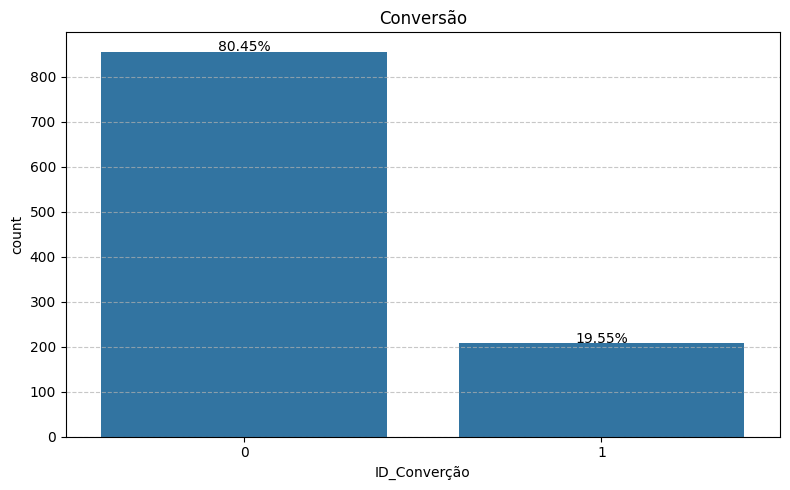

In [ ]:
# Pagamentento (Concluido)
df["ID_Converção"] = df.apply(lambda x: 1 if (x['Última Fase(código)'] == 4) & (x['Status'] == 'Integrada') else 0,axis=1)

plt.figure(figsize=(8,5))
ax = sns.countplot(df, x="ID_Converção")

# Calcular totais
total = len(df)

# Colocar labels em cima das barras
for p in ax.patches:
    count = int(p.get_height())
    perc = 100 * count / total
    ax.text(p.get_x() + p.get_width()/2.,   # posição x
            p.get_height() + 0.2,           # posição y
            f'{round(perc,2)}%',      # texto
            ha='center')                    # centralizado

plt.title("Conversão")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


O gráfico de barras acima descreve a distribuição da variável **ID_Conversão**.  
Observa-se que apenas **19,55%** de todos os clientes do conjunto de dados alcançaram e concluíram a fase de pagamento. Esse valor representa uma fração substancialmente menor em relação ao total de clientes.  



### Distribuição de Clientes por Fases:

Optamos por analisar a quantidade de clientes e seus respectivos Status em cada fase do processo, seguindo uma lógica inversa, isto é, começando pelo final. Na etapa de Pagamento, contabilizamos o total de clientes e observamos que todos apresentavam o Status = Integrada.

Em seguida, retrocedemos para a fase de Averbação, contabilizando os clientes nela presentes. É importante destacar que todos os clientes que avançam para etapas posteriores necessariamente foram aprovados na Averbação. Assim, o total de clientes dessa etapa deve sempre considerar que aqueles que alcançaram a etapa de Pagamento já estão incluídos nesse conjunto. Repetimos o mesmo procedimento até chegar na etapa de Simulação.

------------------------------------------------------------------------------------------------------------------------------------------------------
Fase: Pagamento
------------------------------------------------------------------------------------------------------------------------------------------------------


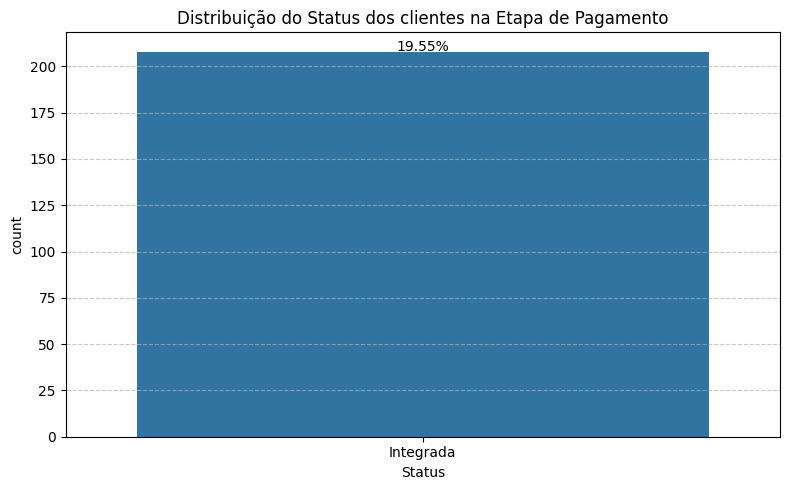

Status
Integrada    208
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
Fase: Averbação
------------------------------------------------------------------------------------------------------------------------------------------------------


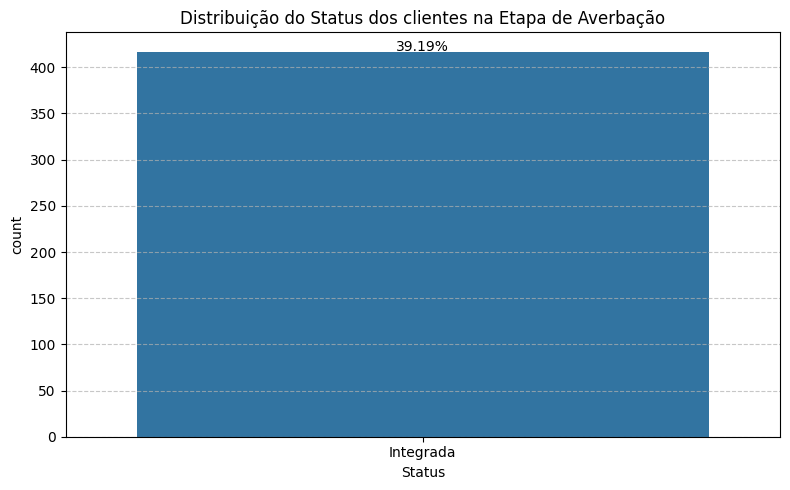

Status
Integrada    417
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
Fase: Análise política de crédito
------------------------------------------------------------------------------------------------------------------------------------------------------


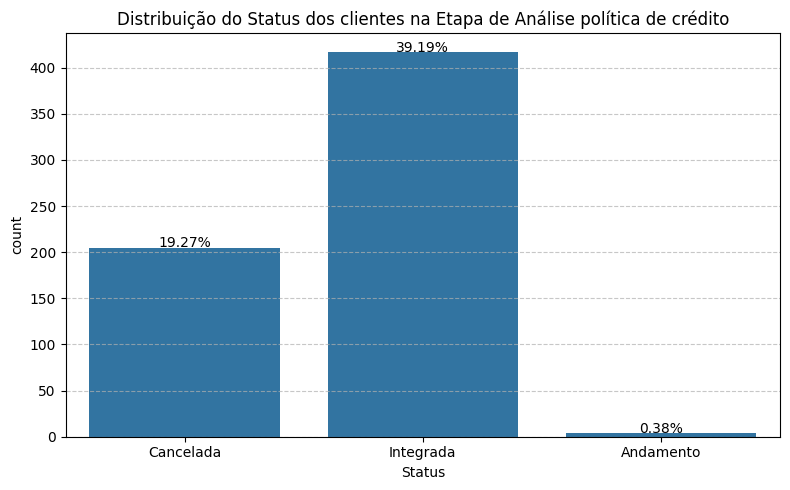

Status
Integrada    417
Cancelada    205
Andamento      4
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
Fase: Análise antifraude
------------------------------------------------------------------------------------------------------------------------------------------------------


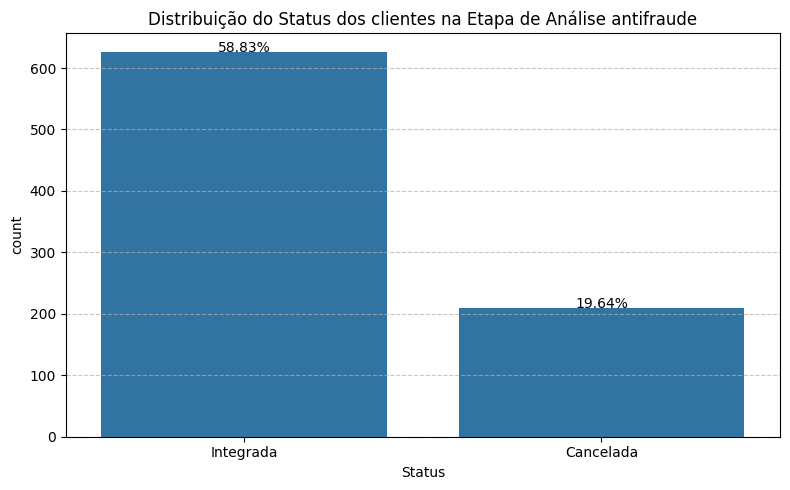

Status
Integrada    626
Cancelada    209
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
Fase: Simulação
------------------------------------------------------------------------------------------------------------------------------------------------------


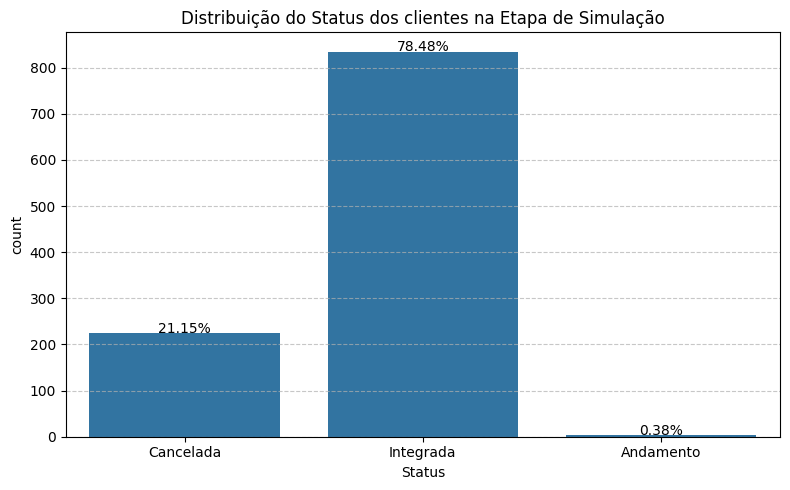

Status
Integrada    835
Cancelada    225
Andamento      4
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------


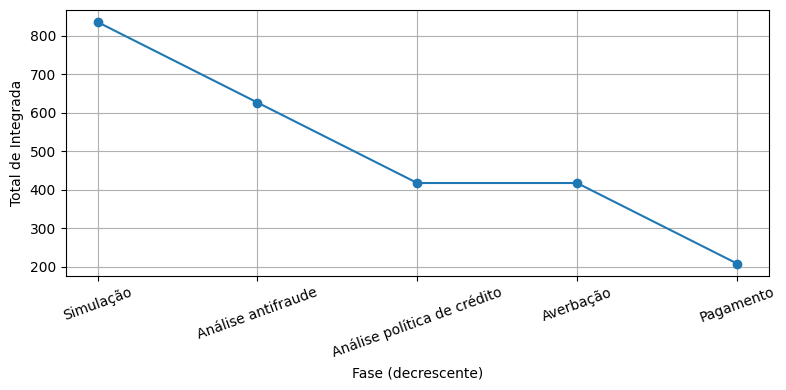

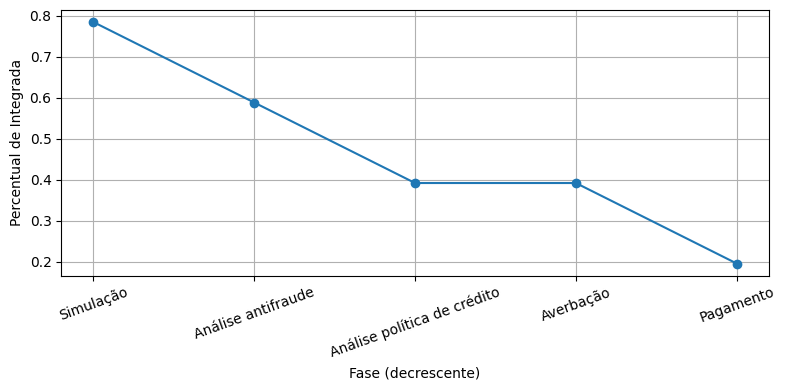

In [10]:
codes = np.arange(4,-1,-1)
dict_code = {0:'Simulação', 1:'Análise antifraude', 2:'Análise política de crédito', 3:'Averbação', 4:'Pagamento'}

Integrada = [] 
Perc_Integrada = []
 
for i in codes:
    if i == 4:
        df_aux = df[df['Última Fase(código)'].isin(np.arange(np.max(codes),i-1,-1))]
    else:
        df_aux = df[df['Última Fase(código)'].isin(np.arange(np.max(codes),i-1,-1))]
        df_aux.loc[df_aux['Última Fase(código)'].isin(np.arange(np.max(codes),i,-1)),'Status'] = 'Integrada'
    
    print(150*'-')
    print(f'Fase: {dict_code[i]}')
    print(150*'-')
    plt.figure(figsize=(8,5))
    ax = sns.countplot(df_aux, x="Status")

    total = len(df)
    for p in ax.patches:
        count = int(p.get_height())
        perc = 100 * count / total
        ax.text(p.get_x() + p.get_width()/2.,   # posição x
                p.get_height() + 0.2,           # posição y
                f'{round(perc,2)}%',      # texto
                ha='center')                    # centralizado

    plt.title(f"Distribuição do Status dos clientes na Etapa de {dict_code[i]}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    Integrada.append(len(df_aux[df_aux['Status']=='Integrada']))
    Perc_Integrada.append(len(df_aux[df_aux['Status']=='Integrada'])/total)
    print(df_aux['Status'].value_counts())
    print(150*'-')

# Curva de Integrada por fase (ordem decrescente)
labels = [dict_code[c] for c in codes[::-1]]
plt.figure(figsize=(8, 4))
plt.plot(labels, Integrada[::-1], marker='o')
plt.ylabel('Total de Integrada')
plt.xlabel('Fase (decrescente)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid()
plt.show()


# Curva de Integrada por fase (ordem decrescente)
labels = [dict_code[c] for c in codes[::-1]]
plt.figure(figsize=(8, 4))
plt.plot(labels, Perc_Integrada[::-1], marker='o')
plt.ylabel('Percentual de Integrada')
plt.xlabel('Fase (decrescente)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid()
plt.show()

Nas figuras acima, apresentamos os gráficos de barras que mostram a distribuição de clientes por Status em cada fase do processo, bem como as curvas que representam a evolução da quantidade e do percentual de clientes com Status = Integrada ao longo das etapas, em relação ao total de clientes. Como esperado, esse percentual diminui progressivamente à medida que os clientes avançam no fluxo. Contudo, observa-se um platô entre as fases de Análise de Política de Crédito e Averbação, seguido por uma queda acentuada na fase de Pagamento. Do ponto de vista da instituição financeira, a conversão se consolida na Averbação, razão pela qual a redução de aproximadamente 20% na etapa de Pagamento constitui um resultado atípico e que merece investigação. Tais perdas, após a Averbação, tendem a estar mais relacionadas a falhas operacionais, desistências por parte dos clientes ou problemas no fluxo de liberação do crédito.

Para validar nossa hipótese refizemos curvas de evolução em quantidade e percentual de clientes com Status = Integrada ao longo das etapas para cada mês no Dataset, aumentando assim sua granularidade.

In [13]:
def analise_exp(df):
    codes = np.arange(4,-1,-1)
    dict_code = {0:'Simulação', 1:'Análise antifraude', 2:'Análise política de crédito', 3:'Averbação', 4:'Pagamento'}

    Integrada = [] 
    Perc_Integrada = []

    total = len(df)
    
    for i in codes:
        if i == 4:
            df_aux = df[df['Última Fase(código)'].isin(np.arange(np.max(codes),i-1,-1))]
        else:
            df_aux = df[df['Última Fase(código)'].isin(np.arange(np.max(codes),i-1,-1))]
            df_aux.loc[df_aux['Última Fase(código)'].isin(np.arange(np.max(codes),i,-1)),'Status'] = 'Integrada'
    
        Integrada.append(len(df_aux[df_aux['Status']=='Integrada']))
        Perc_Integrada.append(len(df_aux[df_aux['Status']=='Integrada'])/total)


    # Curva de Integrada por fase (ordem decrescente)
    labels = [dict_code[c] for c in codes[::-1]]
    plt.figure(figsize=(8, 4))
    plt.plot(labels, Integrada[::-1], marker='o')
    plt.ylabel('Total de Integrada')
    plt.xlabel('Fase (decrescente)')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.grid()
    plt.show()


    # Curva de Integrada por fase (ordem decrescente)
    labels = [dict_code[c] for c in codes[::-1]]
    plt.figure(figsize=(8, 4))
    plt.plot(labels, Perc_Integrada[::-1], marker='o')
    plt.ylabel('Percentual de Integrada')
    plt.xlabel('Fase (decrescente)')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.grid()
    plt.show()
    

## Análise por Mês

------------------------------------------------------------------------------------------------------------------------------------------------------
Mês: 1
------------------------------------------------------------------------------------------------------------------------------------------------------


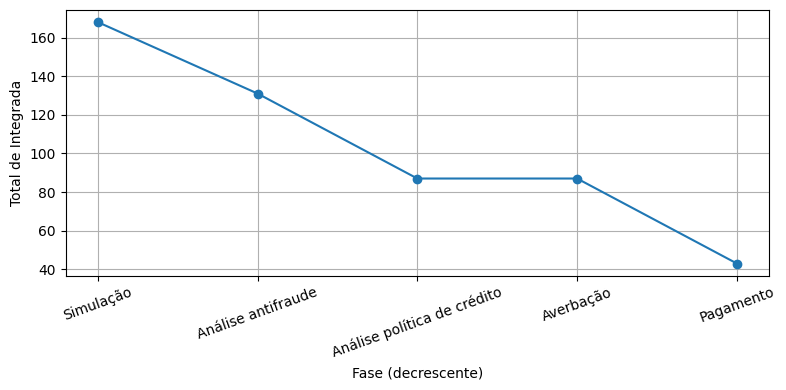

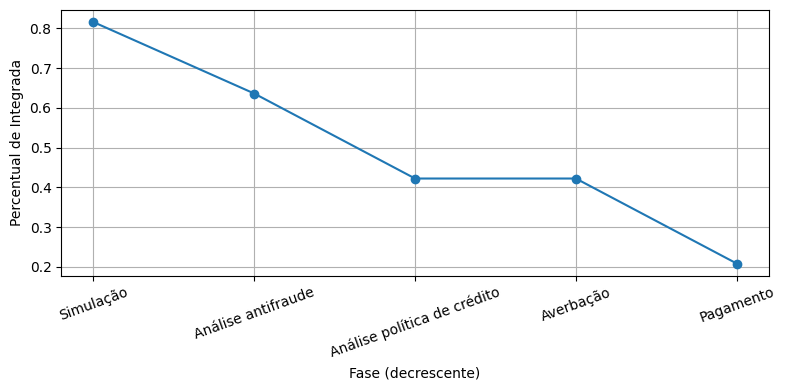

------------------------------------------------------------------------------------------------------------------------------------------------------
Mês: 2
------------------------------------------------------------------------------------------------------------------------------------------------------


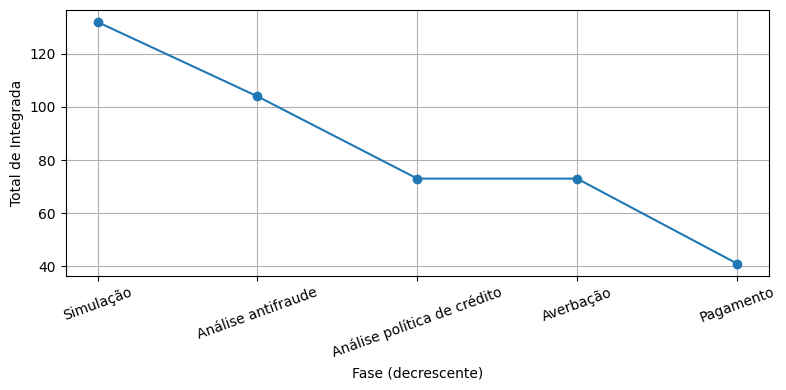

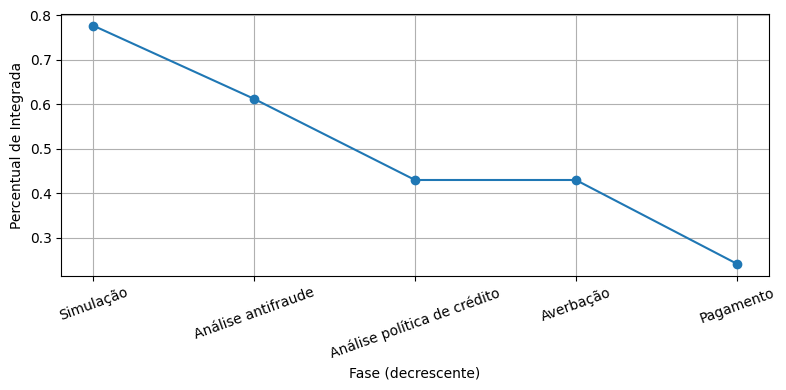

------------------------------------------------------------------------------------------------------------------------------------------------------
Mês: 3
------------------------------------------------------------------------------------------------------------------------------------------------------


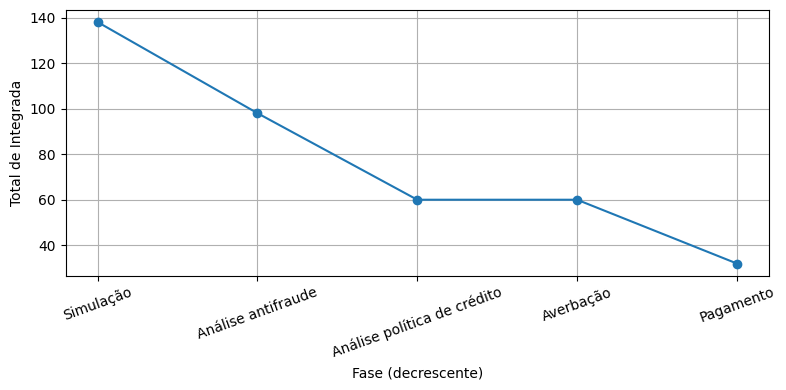

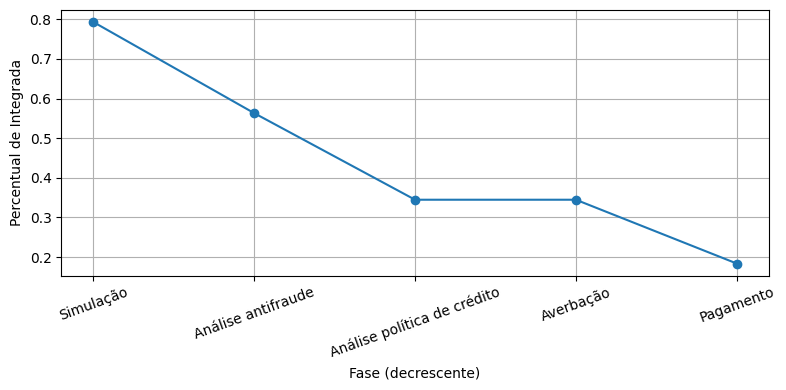

------------------------------------------------------------------------------------------------------------------------------------------------------
Mês: 4
------------------------------------------------------------------------------------------------------------------------------------------------------


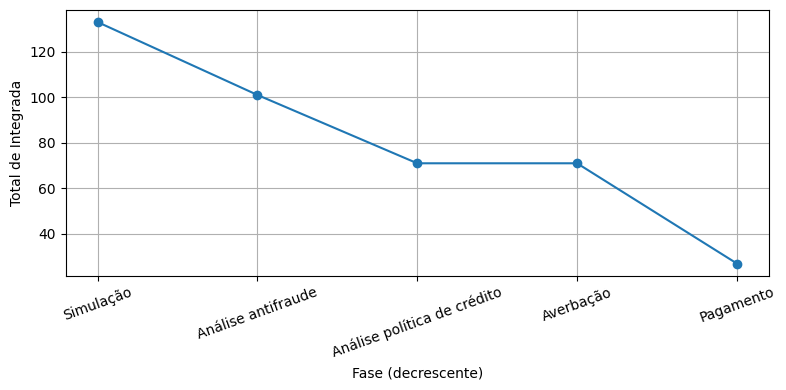

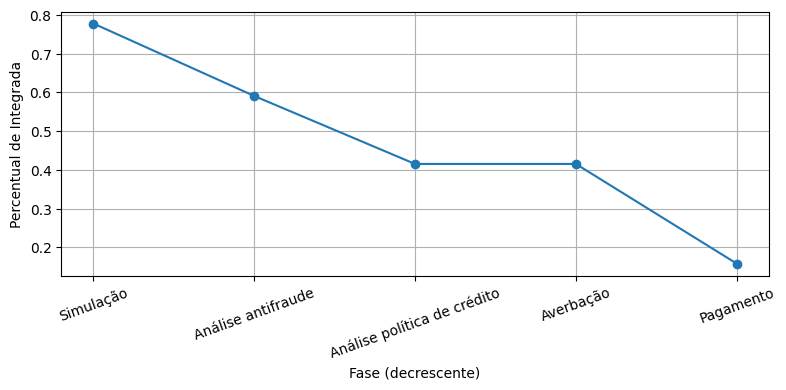

------------------------------------------------------------------------------------------------------------------------------------------------------
Mês: 5
------------------------------------------------------------------------------------------------------------------------------------------------------


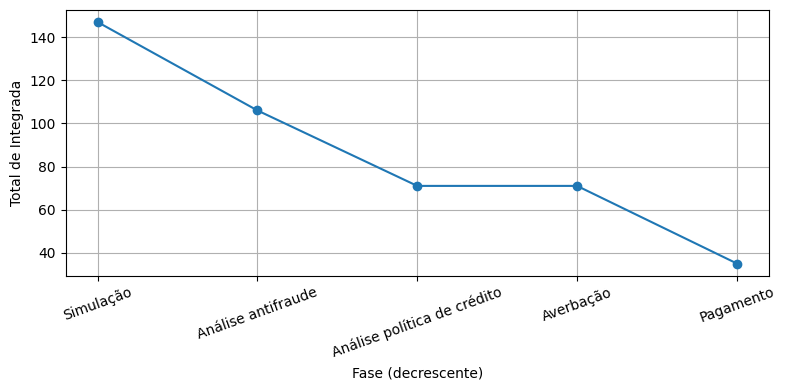

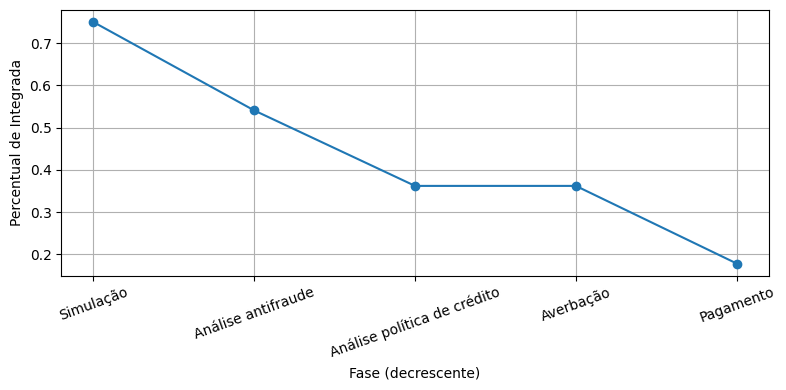

------------------------------------------------------------------------------------------------------------------------------------------------------
Mês: 6
------------------------------------------------------------------------------------------------------------------------------------------------------


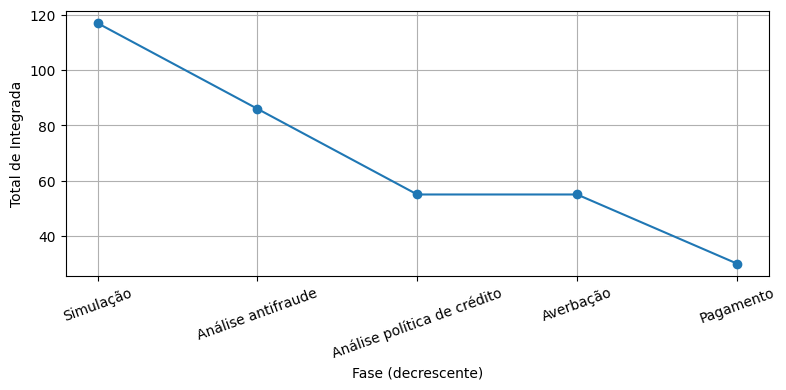

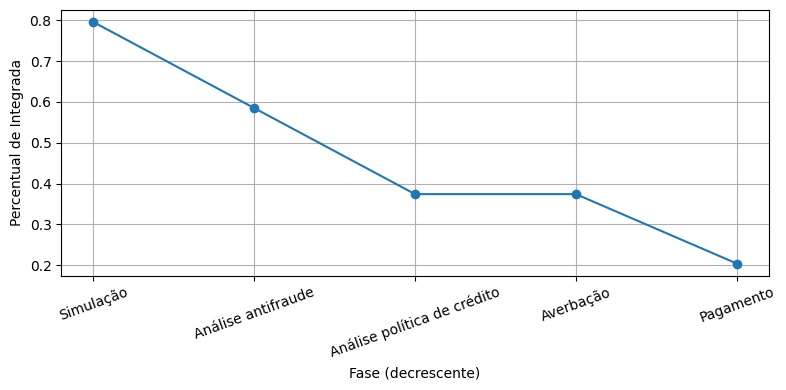

In [14]:
for val in range(1,7):
    print(150*'-')
    print(f'Mês: {val}')
    print(150*'-')
    analise_exp(df[df['Mês']==val])
    

A partir da curva, observamos o mesmo platô presente no resultado anterior, bem como uma proporcionalidade entre os resultados. Portanto, cosntatmos que se trata de um comportamento recorrente, de forma que validamos nossa hipótese.

## Conclusão

À luz de uma análise minuciosa, constatamos um padrão recorrente na etapa de Pagamento: há redução do número de clientes com Status = Integrada, sugerindo que parte dos que passaram pela Averbação — e, portanto, já haviam convertido — não conclui o processo. Nesse contexto, é fundamental que a instituição financeira investigue as causas desse comportamento e adote medidas para mitigá-lo de forma eficaz. As perdas entre Averbação e Pagamento não estão ligadas à política de crédito, mas a falhas operacionais, cadastrais ou de experiência do cliente. Mitigar o problema exige automação, monitoramento de KPIs, validação antecipada de dados e melhoria da comunicação com o cliente.
